In [18]:
import requests
import time
import pandas as pd

BASE_URL = "https://arctic-shift.photon-reddit.com/api/posts/search"

def fetch_subreddit_posts(subreddit, after="2026-03-10", before="2026-04-11", max_posts=50000):
    all_posts = []
    params = {
        "subreddit": subreddit,
        "after": after,
        "before": before,
        "limit": 100,
        "sort": "asc",
    }

    while len(all_posts) < max_posts:
        resp = requests.get(BASE_URL, params=params)
        resp.raise_for_status()
        data = resp.json().get("data", [])

        if not data:
            break

        for post in data:
            if "_meta" in post.keys():
                post["retrieved_2nd_on"] = post["_meta"]["retrieved_2nd_on"]
                del post["_meta"]
                all_posts.append(post)

        last_utc = data[-1]["created_utc"]
        params["after"] = last_utc
        time.sleep(0.5)
        print(f"Collected {len(all_posts)} posts...")

    return pd.DataFrame(all_posts)

In [19]:
df = fetch_subreddit_posts("technology", max_posts=10000)

Collected 100 posts...
Collected 200 posts...
Collected 300 posts...
Collected 400 posts...
Collected 500 posts...
Collected 600 posts...
Collected 700 posts...
Collected 800 posts...
Collected 900 posts...
Collected 1000 posts...
Collected 1100 posts...
Collected 1200 posts...
Collected 1300 posts...
Collected 1400 posts...
Collected 1500 posts...
Collected 1599 posts...
Collected 1699 posts...
Collected 1799 posts...
Collected 1899 posts...
Collected 1999 posts...
Collected 2099 posts...
Collected 2199 posts...
Collected 2299 posts...
Collected 2399 posts...
Collected 2499 posts...
Collected 2599 posts...
Collected 2693 posts...
Collected 2793 posts...
Collected 2842 posts...
Collected 2942 posts...
Collected 3042 posts...
Collected 3142 posts...
Collected 3242 posts...
Collected 3342 posts...
Collected 3442 posts...
Collected 3542 posts...
Collected 3642 posts...
Collected 3742 posts...
Collected 3842 posts...
Collected 3942 posts...
Collected 4042 posts...
Collected 4077 posts...


In [20]:
df.to_csv("reddit_historical.csv")

# Анализ данных

In [1]:
import pandas as pd

df = pd.read_csv("reddit_historical.csv", index_col=0)

# Время заполнения счетчиков

In [2]:
delta = (df["retrieved_2nd_on"] - df["created_utc"]) / 60 / 60

<Axes: ylabel='Count'>

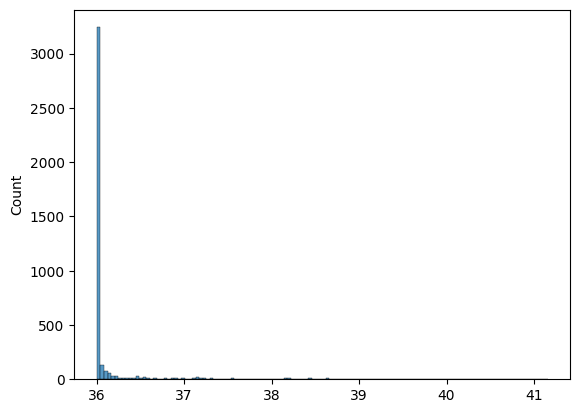

In [3]:
import seaborn as sns
import numpy as np

sns.histplot(delta)

In [4]:
np.percentile(delta, q=95)

np.float64(37.27188888888889)

### Большинство дельт укладывается в диапазон 36-37 ч, далее будем фильтровать

# Определение пустых фичей

In [5]:
null_count = df.isna().sum()
features_to_drop = null_count[null_count == len(df)].index.to_list()

In [6]:
features_to_drop

['approved_at_utc',
 'approved_by',
 'author_flair_background_color',
 'author_flair_css_class',
 'author_flair_template_id',
 'author_flair_text',
 'banned_at_utc',
 'banned_by',
 'category',
 'content_categories',
 'discussion_type',
 'distinguished',
 'likes',
 'link_flair_background_color',
 'mod_note',
 'mod_reason_by',
 'mod_reason_title',
 'num_reports',
 'removed_by',
 'report_reasons',
 'suggested_sort',
 'top_awarded_type',
 'view_count',
 'location_lat',
 'location_long',
 'location_name']

In [7]:
df = df.drop(columns=features_to_drop)

### Определение идентификаторов и фичей с константным значением

In [8]:
cardinality = df.nunique()

In [9]:
poor_features = cardinality[cardinality == 1].index.to_list()
features_to_drop.extend(poor_features)
df = df.drop(columns=poor_features)

In [16]:
UNIQUENESS_THRESHOLD = 0.95

high_cardinality_features = cardinality[cardinality >= len(df) * UNIQUENESS_THRESHOLD].index.to_list()
high_cardinality_features.remove("title")

In [18]:
features_to_drop.extend(high_cardinality_features)

In [19]:
df = df.drop(columns=high_cardinality_features)

### Также удалим необрабатываемые признаки (пока)

In [20]:
df.nunique()

author                    1513
author_fullname           1512
author_premium               2
domain                    1161
is_crosspostable             2
is_reddit_media_domain       2
is_robot_indexable           2
is_self                      2
link_flair_css_class         3
link_flair_template_id      20
link_flair_text             21
locked                       2
media                      141
media_embed                142
no_follow                    2
num_comments               463
num_crossposts              16
over_18                      2
removed_by_category          5
score                      974
secure_media               141
secure_media_embed         160
selftext                     2
send_replies                 2
subreddit_subscribers     3650
thumbnail                 3041
thumbnail_height            88
thumbnail_width              6
title                     3892
ups                        974
upvote_ratio                98
url                       3686
url_over

In [21]:
df["selftext"].unique()

<StringArray>
[nan, '[removed]', '[deleted]']
Length: 3, dtype: str

In [22]:
additional_columns_to_drop = [
    "selftext",
    "url",
    "url_overridden_by_dest",
    "outbound_link",
    "websocket_url"
]

In [23]:
features_to_drop.extend(additional_columns_to_drop)

In [24]:
df = df.drop(columns=additional_columns_to_drop)

In [25]:
pd.set_option("display.max_columns", None)
df.head()

,author,author_fullname,author_premium,domain,is_crosspostable,is_reddit_media_domain,is_robot_indexable,is_self,link_flair_css_class,link_flair_template_id,link_flair_text,locked,media,media_embed,no_follow,num_comments,num_crossposts,over_18,removed_by_category,score,secure_media,secure_media_embed,send_replies,subreddit_subscribers,thumbnail,thumbnail_height,thumbnail_width,title,ups,upvote_ratio,post_hint,preview,crosspost_parent,crosspost_parent_list
0,Abject-Pick-6472,t2_1gndkonzau,False,inc.com,True,False,True,False,general,4264611c-a816-11e9-ae36-0e68c8f218d4,Artificial Intelligence,False,NaN,{},True,111,1,False,NaN,573,NaN,{},True,20174285,default,NaN,NaN,Bad News for Your Burner Account: AI is Surpri...,573,0.93,NaN,NaN,NaN,NaN
1,creaturefeature16,t2_7p5ef,False,theregister.com,True,False,True,False,general,4264611c-a816-11e9-ae36-0e68c8f218d4,Artificial Intelligence,False,NaN,{},True,14,0,False,NaN,142,NaN,{},True,20174295,https://external-preview.redd.it/ieRYQKaGO6JbR...,93.0,140.0,"AI-built app on Lovable exposed 18K users, res...",142,0.96,link,"{'enabled': False, 'images': [{'id': 'ieRYQKaG...",NaN,NaN
2,No-Performance-9730,t2_da6fel0x,False,pantherahive.com,False,False,False,False,general,4264611c-a816-11e9-ae36-0e68c8f218d4,Artificial Intelligence,False,NaN,{},True,1,0,True,moderator,1,NaN,{},True,20174305,nsfw,NaN,NaN,2 new technologies auto script +voice+ veo 2 +...,1,1.00,NaN,NaN,NaN,NaN
3,Kitchen_Biscotti_747,t2_d3ph7a05,False,beincrypto.com,False,False,False,False,general,4264611c-a816-11e9-ae36-0e68c8f218d4,Artificial Intelligence,False,NaN,{},True,0,0,False,moderator,1,NaN,{},True,20174306,default,NaN,NaN,Anthropic’s Legal War With Trump Could Hit AI ...,1,1.00,NaN,NaN,NaN,NaN
4,AnonymousTimewaster,t2_1b3euocai5,False,cybernews.com,False,False,False,False,general,4264611c-a816-11e9-ae36-0e68c8f218d4,Artificial Intelligence,False,NaN,{},True,0,0,False,moderator,1,NaN,{},True,20174334,default,NaN,NaN,Viral GitHub project claims WiFi can ‘see thro...,1,1.00,NaN,NaN,NaN,NaN


In [26]:
df.nunique()

author                    1513
author_fullname           1512
author_premium               2
domain                    1161
is_crosspostable             2
is_reddit_media_domain       2
is_robot_indexable           2
is_self                      2
link_flair_css_class         3
link_flair_template_id      20
link_flair_text             21
locked                       2
media                      141
media_embed                142
no_follow                    2
num_comments               463
num_crossposts              16
over_18                      2
removed_by_category          5
score                      974
secure_media               141
secure_media_embed         160
send_replies                 2
subreddit_subscribers     3650
thumbnail                 3041
thumbnail_height            88
thumbnail_width              6
title                     3892
ups                        974
upvote_ratio                98
post_hint                    4
preview                   3046
crosspos

### Ищем корреляции количественных признаков с таргетом

<Axes: >

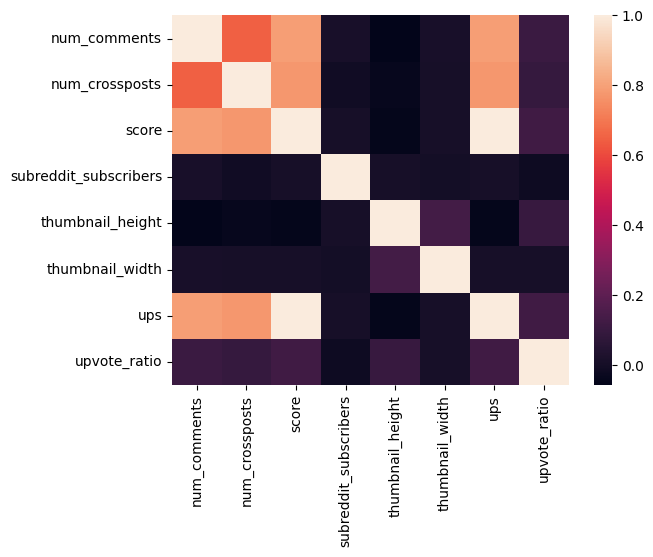

In [33]:
corr = df.select_dtypes('number').corr()
sns.heatmap(corr)

### ups и score могут давать утечку данных - уберем также и их

In [36]:
df = df.drop(columns=["ups", "score", "upvote_ratio"])

In [40]:
# удалим таргет
df = df.drop(columns=["num_comments"])

In [38]:
import yaml

features_to_select = df.columns.to_list()


output = yaml.dump(features_to_select, explicit_start=True, default_flow_style=False)

In [39]:
print(output)

---
- author
- author_fullname
- author_premium
- domain
- is_crosspostable
- is_reddit_media_domain
- is_robot_indexable
- is_self
- link_flair_css_class
- link_flair_template_id
- link_flair_text
- locked
- media
- media_embed
- no_follow
- num_comments
- num_crossposts
- over_18
- removed_by_category
- secure_media
- secure_media_embed
- send_replies
- subreddit_subscribers
- thumbnail
- thumbnail_height
- thumbnail_width
- title
- upvote_ratio
- post_hint
- preview
- crosspost_parent
- crosspost_parent_list

